In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/CustomerChurn.csv")
df.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [5]:
target = "Churn"
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

In [6]:
# Method 1: Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importance
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,Tenure,0.146427
18,Monthly Charges,0.129828
19,Total Charges,0.119029
0,LoyaltyID,0.113336
1,Customer ID,0.110565
15,Contract,0.081031
9,Online Security,0.042835
17,Payment Method,0.038854
12,Tech Support,0.033433
8,Internet Service,0.025741


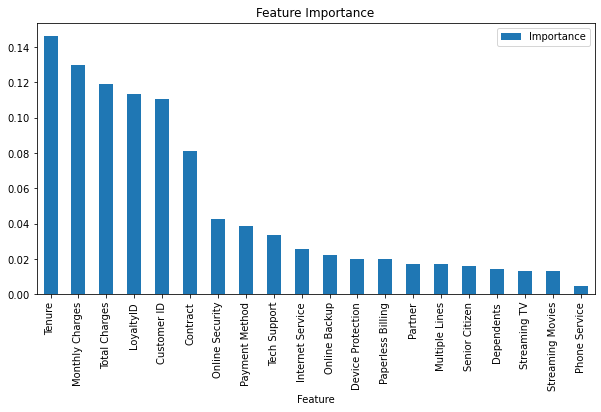

In [7]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

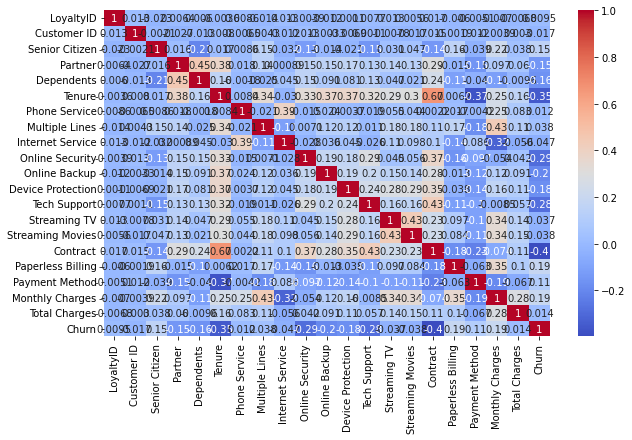

In [8]:
# Method 2: Correlation Matrix
corr = df_encoded.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [9]:
corr.loc["Tenure", "Total Charges"]

0.1585229609002224

In [10]:
corr.loc["Monthly Charges", "Churn"]

0.19335642223784716

In [11]:
corr.loc["Tenure", "Churn"]

-0.35222867011307885

In [12]:
# Method 3: Chi-Square Test
from sklearn.feature_selection import chi2

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

chi_scores = chi2(X, y)

chi_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores[0]
}).sort_values(by="Chi2 Score", ascending=False)

chi_results

,Feature,Chi2 Score
0,LoyaltyID,78735.723837
5,Tenure,16278.923685
18,Monthly Charges,3680.787699
1,Customer ID,2516.968803
19,Total Charges,1616.483021
15,Contract,1115.780167
9,Online Security,551.611529
12,Tech Support,523.577664
10,Online Backup,230.086520
11,Device Protection,191.303140


In [13]:
df_final = df[["Tenure", "Monthly Charges", "Multiple Lines", "Churn"]]

In [14]:
df_final.head()

,Tenure,Monthly Charges,Multiple Lines,Churn
0,1,29.85,No phone service,No
1,34,56.95,No,No
2,2,53.85,No,Yes
3,45,42.30,No phone service,No
4,2,70.70,No,Yes


In [15]:
df_final.to_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/selected_features.csv", index=False)

In [16]:
# Keep only the 4 relevant columns (3 predictors + target)
# Work on a fresh copy so we never mutate the raw dataframe
df_model = df[["Tenure", "Monthly Charges", "Multiple Lines", "Churn"]].copy()

print("Selected columns:", df_model.columns.tolist())
print("Shape:", df_model.shape)
df_model.head()

Selected columns: ['Tenure', 'Monthly Charges', 'Multiple Lines', 'Churn']
Shape: (7043, 4)


,Tenure,Monthly Charges,Multiple Lines,Churn
0,1,29.85,No phone service,No
1,34,56.95,No,No
2,2,53.85,No,Yes
3,45,42.30,No phone service,No
4,2,70.70,No,Yes


In [17]:
# Missing value audit
print("Missing values per column:")
print(df_model.isnull().sum())
print()
print("Multiple Lines unique values:", df_model["Multiple Lines"].unique())

Missing values per column:
Tenure             0
Monthly Charges    0
Multiple Lines     0
Churn              0
dtype: int64

Multiple Lines unique values: ['No phone service' 'No' 'Yes']


In [19]:
# Set threshold for ranges of tenure
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Established"
    else:
        return "Loyal"

df_model["Tenure Group"] = df_model["Tenure"].apply(tenure_group)
print(df_model["Tenure Group"].value_counts())

Loyal          3001
New            2186
Established    1856
Name: Tenure Group, dtype: int64


In [20]:
# Create ChargeLevels for ranges of Monthly Charges
def charge_level(x):
    if x < 35:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"
df_model["Charge Level"] = df_model["Monthly Charges"].apply(charge_level)
print(df_model["Charge Level"].value_counts())

High      3591
Low       1731
Medium    1721
Name: Charge Level, dtype: int64


In [21]:
df_model["Multiple Lines"] = df_model["Multiple Lines"].map({
    "No phone service": 0,
    "No": 1,
    "Yes": 2
})

In [22]:
df["Multiple Lines"].value_counts(dropna=False)

No                  3390
Yes                 2971
No phone service     682
Name: Multiple Lines, dtype: int64

In [32]:
# Tenure Group — ordinal encode (order matters: New < Established < Loyal)
tenure_order = ["New", "Established", "Loyal"]
df_model["Tenure Group"] = pd.Categorical(
    df_model["Tenure Group"], categories=tenure_order, ordered=True
).codes
# Result: New=0, Established=1, Loyal=2

# Charge Level — ordinal encode (order matters: Low < Medium < High)
charge_order = ["Low", "Medium", "High"]
df_model["Charge Level"] = pd.Categorical(
    df_model["Charge Level"], categories=charge_order, ordered=True
).codes
# Result: Low=0, Medium=1, High=2

# Churn — binary encode target variable
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

print("Encoding complete.")
print("Churn distribution:")
print(df_model["Churn"].value_counts())

Encoding complete.
Churn distribution:
Series([], Name: Churn, dtype: int64)


In [34]:
df_model = df_model[[
    "Tenure Group",    # loyalty indicator  (0=New, 1=Established, 2=Loyal)
    "Charge Level",    # price sensitivity  (0=Low, 1=Medium, 2=High)
    "Multiple Lines",  # engagement level   (0=No phone, 1=Single, 2=Multiple)
    "Churn"            # target variable    (0=No churn, 1=Churned)
]]

print("Final dataframe shape:", df_model.shape)
print()
print("Missing values:")
print(df_model.isnull().sum())
print()
print("Data types:")
print(df_model.dtypes)

Final dataframe shape: (7043, 4)

Missing values:
Tenure Group         0
Charge Level         0
Multiple Lines       0
Churn             7043
dtype: int64

Data types:
Tenure Group         int8
Charge Level         int8
Multiple Lines      int64
Churn             float64
dtype: object


In [30]:
df_model.head(10)

,Tenure Group,Charge Level,Multiple Lines,Churn
0,-1,-1,0,NaN
1,-1,-1,1,NaN
2,-1,-1,1,NaN
3,-1,-1,0,NaN
4,-1,-1,1,NaN
5,-1,-1,2,NaN
6,-1,-1,2,NaN
7,-1,-1,0,NaN
8,-1,-1,2,NaN
9,-1,-1,1,NaN


In [24]:
df_model.shape

(7043, 6)

In [25]:
df_model.columns

Index(['Tenure', 'Monthly Charges', 'Multiple Lines', 'Tenure Group',
       'Charge Level', 'Churn'],
      dtype='object')

In [26]:
df_model.head()

,Tenure,Monthly Charges,Multiple Lines,Tenure Group,Charge Level,Churn
0,1,29.85,NaN,1,142,No
1,34,56.95,0.0,34,498,No
2,2,53.85,0.0,2,436,Yes
3,45,42.30,NaN,45,266,No
4,2,70.70,0.0,2,729,Yes


In [ ]:
# Multiple Lines — encode with 3-category structure preserved
#   'No phone service' -> 0  (no phone engagement at all)
#   'No'               -> 1  (single line — light engagement)
#   'Yes'              -> 2  (multiple lines — deep engagement)

df_model["Multiple Lines"] = df_model["Multiple Lines"].map({
    "No phone service": 0,
    "No": 1,
    "Yes": 2
})

print("Multiple Lines distribution after encoding:")
print(df_model["Multiple Lines"].value_counts(dropna=False))
print()
print("NaN count:", df_model["Multiple Lines"].isnull().sum(), "<-- should be 0"